# Séance 03 - Machine Learning Avancé
## EFREI Paris - M2 DEV G1
**Instructeur:** Babacar GUEYE

### Thèmes couverts:
1. Arbre de Décision vs Random Forest
2. Analyse en Composantes Principales (PCA)
3. Impact de la standardisation sur les algorithmes sensibles

## Imports et Dépendances

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_digits, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Configuration de l'affichage
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

## 1. Arbre de Décision vs Random Forest

Comparaison entre un modèle d'arbre unique et un ensemble d'arbres (Random Forest).

In [23]:
# Charger le dataset Wine
wine = load_wine()
X = wine.data
y = wine.target

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset Wine:")
print(f"  Nombre d'échantillons: {len(X)}")
print(f"  Nombre de features: {X.shape[1]}")
print(f"  Nombre de classes: {len(np.unique(y))}")
print(f"  Feature names: {wine.feature_names}")

Dataset Wine:
  Nombre d'échantillons: 178
  Nombre de features: 13
  Nombre de classes: 3
  Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [24]:
# Entraîner un arbre de décision simple
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Arbre de Décision:")
print(f"  Précision (Accuracy): {dt_accuracy:.4f}")
print(f"  Profondeur maximale: 5")
print(f"  Nombre de feuilles: {dt.get_n_leaves()}")

Arbre de Décision:
  Précision (Accuracy): 0.9630
  Profondeur maximale: 5
  Nombre de feuilles: 7


In [25]:
# Entraîner un Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest:")
print(f"  Précision (Accuracy): {rf_accuracy:.4f}")
print(f"  Nombre d'arbres: 100")
print(f"  Profondeur maximale: 5")
print(f"\nGain de performance: {(rf_accuracy - dt_accuracy):.4f} ({((rf_accuracy - dt_accuracy)/dt_accuracy * 100):.2f}%)")

Random Forest:
  Précision (Accuracy): 1.0000
  Nombre d'arbres: 100
  Profondeur maximale: 5

Gain de performance: 0.0370 (3.85%)


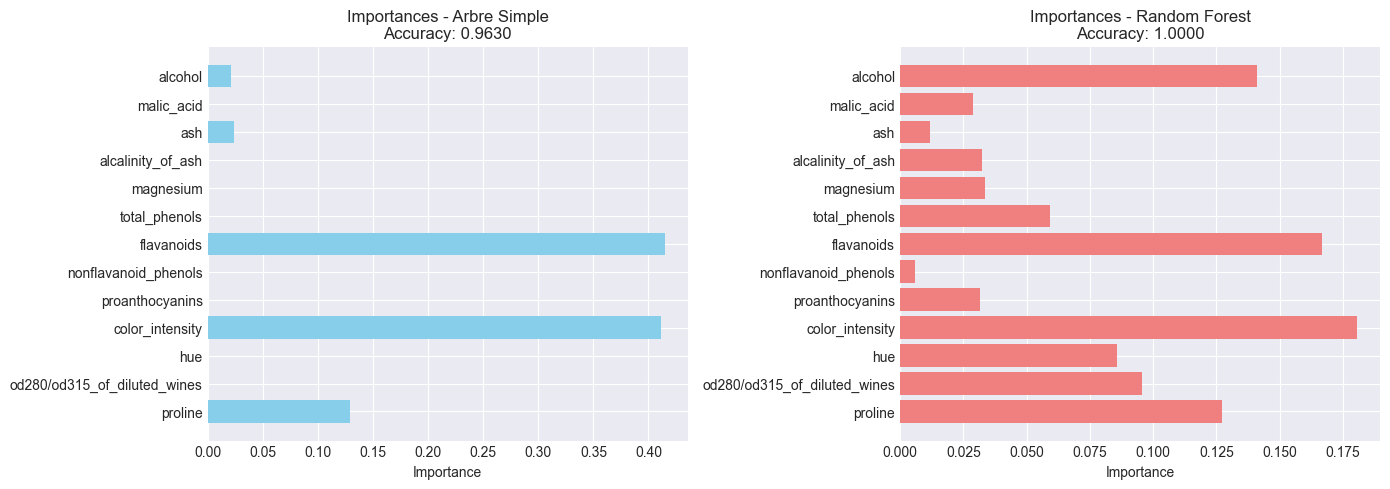


Top 5 features importants (Random Forest):
  color_intensity: 0.1806
  flavanoids: 0.1666
  alcohol: 0.1410
  proline: 0.1273
  od280/od315_of_diluted_wines: 0.0955


In [26]:
# Comparaison des importances de features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Arbre de décision
dt_importances = dt.feature_importances_
axes[0].barh(wine.feature_names, dt_importances, color='skyblue')
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Importances - Arbre Simple\nAccuracy: {dt_accuracy:.4f}')
axes[0].invert_yaxis()

# Random Forest
rf_importances = rf.feature_importances_
axes[1].barh(wine.feature_names, rf_importances, color='lightcoral')
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Importances - Random Forest\nAccuracy: {rf_accuracy:.4f}')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 5 features importants (Random Forest):")
top_indices = np.argsort(rf_importances)[-5:][::-1]
for idx in top_indices:
    print(f"  {wine.feature_names[idx]}: {rf_importances[idx]:.4f}")

## 2. PCA - Analyse en Composantes Principales sur le Dataset Digits

Réduction de dimensionnalité et visualisation.

In [27]:
# Charger le dataset Digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Dataset Digits:")
print(f"  Nombre d'échantillons: {len(X_digits)}")
print(f"  Nombre de features (pixels): {X_digits.shape[1]} (8x8)")
print(f"  Nombre de classes: {len(np.unique(y_digits))}")

Dataset Digits:
  Nombre d'échantillons: 1797
  Nombre de features (pixels): 64 (8x8)
  Nombre de classes: 10


In [28]:
# Appliquer PCA avec 2 composantes
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_digits)

print(f"PCA avec 2 composantes:")
print(f"  Variance expliquée par composante: {pca_2.explained_variance_ratio_}")
print(f"  Variance totale expliquée: {pca_2.explained_variance_ratio_.sum():.4f}")

PCA avec 2 composantes:
  Variance expliquée par composante: [0.14890594 0.13618771]
  Variance totale expliquée: 0.2851


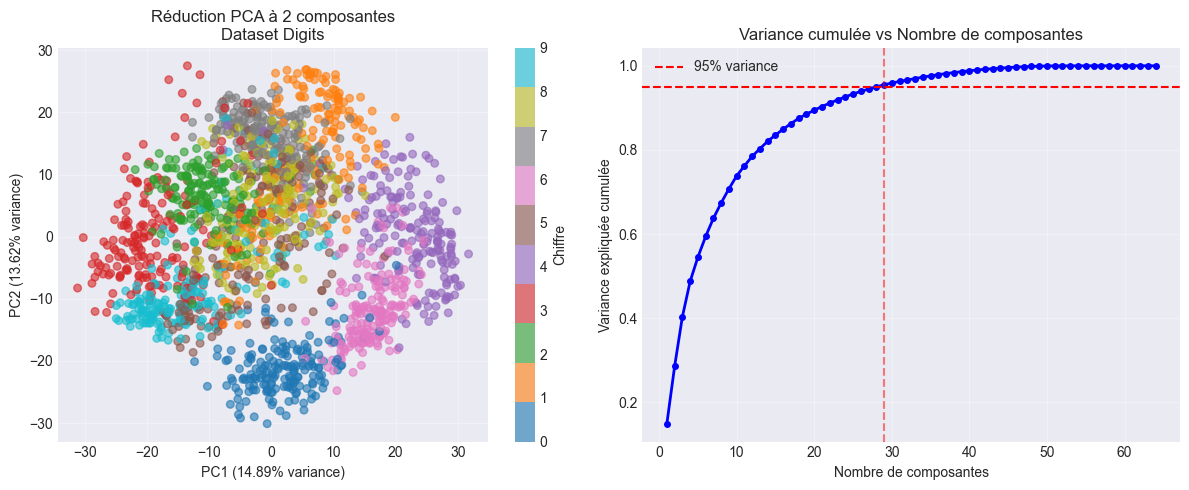


Nombre de composantes pour 95% de variance: 29
Réduction dimensionnelle: 64 -> 29 (45.3%)


In [29]:
# Visualiser les 2 composantes principales
plt.figure(figsize=(12, 5))

# Scatter plot 2D
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y_digits, cmap='tab10', alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Réduction PCA à 2 composantes\nDataset Digits')
plt.colorbar(scatter, label='Chiffre')
plt.grid(True, alpha=0.3)

# Variance expliquée cumulée
pca_full = PCA()
pca_full.fit(X_digits)
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2, markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=np.argmax(cumsum_var >= 0.95) + 1, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance cumulée vs Nombre de composantes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"\nNombre de composantes pour 95% de variance: {n_components_95}")
print(f"Réduction dimensionnelle: {X_digits.shape[1]} -> {n_components_95} ({(n_components_95/X_digits.shape[1]*100):.1f}%)")

Les composantes et leur variance

In [30]:
# Listing détaillé de chaque composante et sa variance expliquée
variance_df = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'Variance expliquée (%)': pca_full.explained_variance_ratio_ * 100,
    'Variance cumulée (%)': np.cumsum(pca_full.explained_variance_ratio_) * 100
})

print("=== Listing des composantes PCA et leur variance ===\n")
print(variance_df.to_string(index=False, float_format='%.4f'))

# Mettre en évidence les composantes les plus importantes
print(f"\n--- Top 10 composantes les plus explicatives ---")
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    bar = '█' * int(pca_full.explained_variance_ratio_[i] * 100)
    print(f"  PC{i+1:2d}: {pca_full.explained_variance_ratio_[i]*100:6.2f}%  {bar}")

print(f"\n--- Seuils clés ---")
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumsum_var >= threshold) + 1
    print(f"  {threshold:.0%} de variance → {n} composantes (sur {X_digits.shape[1]})")

=== Listing des composantes PCA et leur variance ===

Composante  Variance expliquée (%)  Variance cumulée (%)
       PC1                 14.8906               14.8906
       PC2                 13.6188               28.5094
       PC3                 11.7946               40.3040
       PC4                  8.4100               48.7139
       PC5                  5.7824               54.4964
       PC6                  4.9169               59.4133
       PC7                  4.3160               63.7293
       PC8                  3.6614               67.3906
       PC9                  3.3532               70.7439
      PC10                  3.0788               73.8227
      PC11                  2.3723               76.1950
      PC12                  2.2727               78.4677
      PC13                  1.8219               80.2896
      PC14                  1.7739               82.0634
      PC15                  1.4671               83.5305
      PC16                  1.4097

## 3. Impact de la Standardisation sur SVM

Démonstration de l'importance de la normalisation pour les algorithmes sensibles à l'échelle.

In [32]:
# Générer des données avec des échelles très différentes
from sklearn.datasets import make_classification

X_scale, y_scale = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42,
    class_sep=1.0
)

# Créer des features avec des échelles très différentes
X_unscaled = X_scale.copy()
X_unscaled[:, 0] *= 1000  # Première feature: beaucoup plus grande
X_unscaled[:, 1] *= 0.01  # Deuxième feature: beaucoup plus petite

# Division train/test
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unscaled, y_scale, test_size=0.3, random_state=42
)

print(f"Données non standardisées:")
print(f"  Feature 0 - Min: {X_unscaled[:, 0].min():.2f}, Max: {X_unscaled[:, 0].max():.2f}")
print(f"  Feature 1 - Min: {X_unscaled[:, 1].min():.4f}, Max: {X_unscaled[:, 1].max():.4f}")
print(f"  Ratio d'échelle: {X_unscaled[:, 0].max() / (X_unscaled[:, 1].max() + 1e-10):.0f}x")

Données non standardisées:
  Feature 0 - Min: -2671.22, Max: 3947.35
  Feature 1 - Min: -0.0271, Max: 0.0262
  Ratio d'échelle: 150845x


In [33]:
# SVM sans standardisation
svm_no_scale = SVC(kernel='rbf', random_state=42)
svm_no_scale.fit(X_train_u, y_train_u)
pred_no_scale = svm_no_scale.predict(X_test_u)
acc_no_scale = accuracy_score(y_test_u, pred_no_scale)

print(f"SVM SANS standardisation:")
print(f"  Accuracy: {acc_no_scale:.4f}")

SVM SANS standardisation:
  Accuracy: 0.9222


In [34]:
# Standardiser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_u)
X_test_scaled = scaler.transform(X_test_u)

# SVM avec standardisation
svm_scaled = SVC(kernel='rbf', random_state=42)
svm_scaled.fit(X_train_scaled, y_train_u)
pred_scaled = svm_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test_u, pred_scaled)

print(f"SVM AVEC standardisation:")
print(f"  Accuracy: {acc_scaled:.4f}")
print(f"\nAmélioration: {(acc_scaled - acc_no_scale):.4f} ({((acc_scaled - acc_no_scale)/acc_no_scale * 100):.1f}%)")

SVM AVEC standardisation:
  Accuracy: 0.9556

Amélioration: 0.0333 (3.6%)


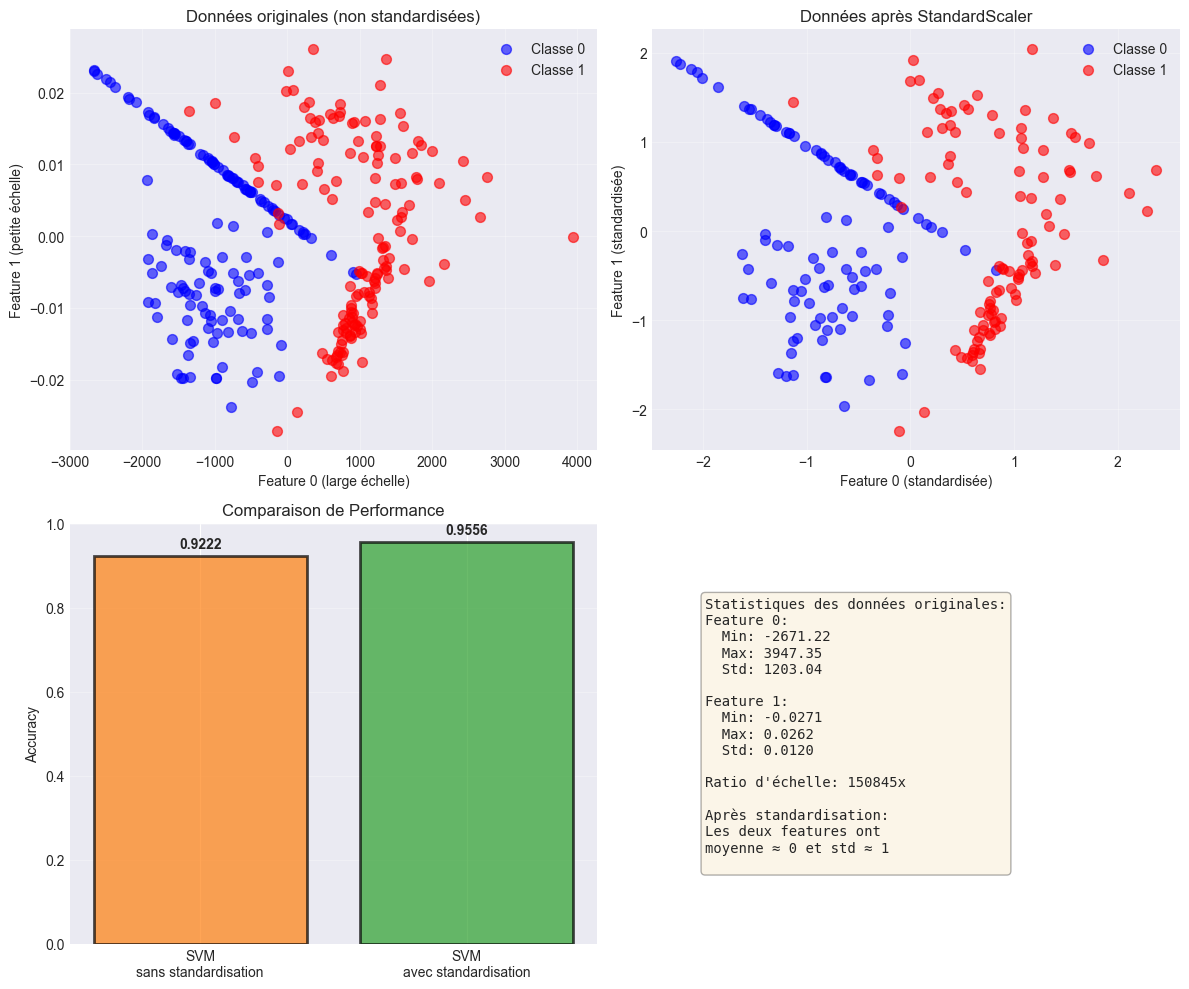

In [35]:
# Visualiser l'impact de la standardisation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Données non standardisées
axes[0, 0].scatter(X_unscaled[y_scale == 0, 0], X_unscaled[y_scale == 0, 1], 
                   c='blue', label='Classe 0', alpha=0.6, s=50)
axes[0, 0].scatter(X_unscaled[y_scale == 1, 0], X_unscaled[y_scale == 1, 1], 
                   c='red', label='Classe 1', alpha=0.6, s=50)
axes[0, 0].set_xlabel('Feature 0 (large échelle)')
axes[0, 0].set_ylabel('Feature 1 (petite échelle)')
axes[0, 0].set_title('Données originales (non standardisées)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Données standardisées
axes[0, 1].scatter(X_train_scaled[y_train_u == 0, 0], X_train_scaled[y_train_u == 0, 1], 
                   c='blue', label='Classe 0', alpha=0.6, s=50)
axes[0, 1].scatter(X_train_scaled[y_train_u == 1, 0], X_train_scaled[y_train_u == 1, 1], 
                   c='red', label='Classe 1', alpha=0.6, s=50)
axes[0, 1].set_xlabel('Feature 0 (standardisée)')
axes[0, 1].set_ylabel('Feature 1 (standardisée)')
axes[0, 1].set_title('Données après StandardScaler')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Comparaison d'accuracy
models = ['SVM\nsans standardisation', 'SVM\navec standardisation']
accuracies = [acc_no_scale, acc_scaled]
colors = ['#ff7f0e', '#2ca02c']

axes[1, 0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].set_title('Comparaison de Performance')
for i, acc in enumerate(accuracies):
    axes[1, 0].text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Statistiques des données
stats_text = f"""Statistiques des données originales:
Feature 0:
  Min: {X_unscaled[:, 0].min():.2f}
  Max: {X_unscaled[:, 0].max():.2f}
  Std: {X_unscaled[:, 0].std():.2f}

Feature 1:
  Min: {X_unscaled[:, 1].min():.4f}
  Max: {X_unscaled[:, 1].max():.4f}
  Std: {X_unscaled[:, 1].std():.4f}

Ratio d'échelle: {X_unscaled[:, 0].max() / X_unscaled[:, 1].max():.0f}x

Après standardisation:
Les deux features ont
moyenne ≈ 0 et std ≈ 1
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Résumé et Points Clés

### 1. Arbre de Décision vs Random Forest
- **Arbre simple** : Rapide, interprétable, mais sujet à l'overfitting
- **Random Forest** : Plus robuste, généralement meilleure performance grâce à l'ensemble d'arbres
- **Importances** : Random Forest donne une meilleure indication de l'importance moyenne des features

### 2. PCA (Analyse en Composantes Principales)
- Technique non-supervisée de réduction dimensionnelle
- Utile pour la visualisation et l'accélération de modèles coûteux
- Trade-off entre réduction dimensionnelle et variance expliquée
- Perte d'interprétabilité mais gain computational

### 3. Standardisation et Normalisation
- **Essentielle pour** : SVM, KNN, Régression Logistique, Réseaux Neuronaux
- **Moins critique pour** : Arbres de Décision, Random Forest
- StandardScaler: (x - μ) / σ
- Impact majeur sur la convergence et les performances